 Movie Review Sentiment Analysis Project

[1/6] Loading Kaggle dataset (train.tsv)...
[2/6] Formatting 5-Class Kaggle data into Binary (Positive/Negative)...
      Cleaning text data (removing HTML, punctuation, etc.)...
[3/6] Splitting data into training (80%) and testing (20%) sets...
[4/6] Vectorizing text using TF-IDF (Term Frequency-Inverse Document Frequency)...
[5/6] Tuning and training Multinomial Naive Bayes model...
      Best hyperparameters found: {'alpha': 0.1}
[6/6] Evaluating the model on test data...

================ RESULTS ================
Overall Accuracy: 83.41%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.76      0.80      6785
    Positive       0.82      0.89      0.86      8511

    accuracy                           0.83     15296
   macro avg       0.84      0.83      0.83     15296
weighted avg       0.84      0.83      0.83     15296

[*] Confusion matrix visualization saved as 'confu

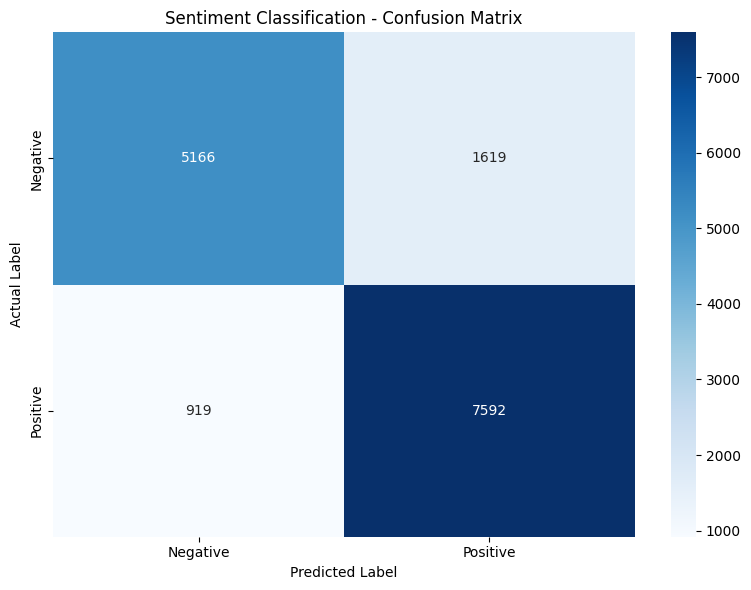

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def clean_text(text):

    text = re.sub(r'<.*?>', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

def plot_confusion_matrix(y_true, y_pred, classes, filename='confusion_matrix.png'):

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Sentiment Classification - Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename)
    print(f"[*] Confusion matrix visualization saved as '{filename}'")

def main():
    print("=========================================")
    print(" Movie Review Sentiment Analysis Project")
    print("=========================================\n")

    print("[1/6] Loading Kaggle dataset (train.tsv)...")
    try:
        df = pd.read_csv('train.tsv', sep='\t')
    except FileNotFoundError:
        print("Error: Dataset not found. Ensure 'train.tsv' is in the current directory.")
        return

    print("[2/6] Formatting 5-Class Kaggle data into Binary (Positive/Negative)...")
    df = df[df['Sentiment'] != 2].copy()

    df['Binary_Sentiment'] = df['Sentiment'].apply(lambda x: 1 if x > 2 else 0)

    print("      Cleaning text data (removing HTML, punctuation, etc.)...")
    df['cleaned_review'] = df['Phrase'].apply(clean_text)

    print("[3/6] Splitting data into training (80%) and testing (20%) sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        df['cleaned_review'], df['Binary_Sentiment'], test_size=0.2, random_state=42
    )

    print("[4/6] Vectorizing text using TF-IDF (Term Frequency-Inverse Document Frequency)...")
    vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    print("[5/6] Tuning and training Multinomial Naive Bayes model...")
    param_grid = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]}
    nb_model = MultinomialNB()
    grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_tfidf, y_train)

    best_model = grid_search.best_estimator_
    print(f"      Best hyperparameters found: {grid_search.best_params_}")

    print("[6/6] Evaluating the model on test data...")
    predictions = best_model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    print(f"\n================ RESULTS ================")
    print(f"Overall Accuracy: {accuracy * 100:.2f}%")
    print("=========================================\n")

    print("Detailed Classification Report:")
    print(classification_report(y_test, predictions, target_names=['Negative', 'Positive']))

    plot_confusion_matrix(y_test, predictions, classes=['Negative', 'Positive'])

    joblib.dump(best_model, 'naive_bayes_model.pkl')
    joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
    print("[*] Model and Vectorizer successfully saved to disk (.pkl files).")
    print("Process Complete.")

if __name__ == "__main__":
    main()